# PixelDrop — Pandas Project
## Notebook 05: Visualisations

**Goal:** Build portfolio-ready charts that tell the PixelDrop story visually.

**Charts in this notebook:**
1. Weekly sales trend (2 years)
2. Monthly revenue heatmap (month x day of week)
3. Shipping days vs return rate
4. Order value distribution
5. Revenue trend with MoM growth
6. Customer segment revenue waterfall

## Step 1: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
BRAND_COLOR  = '#1B1F3B'
ACCENT_COLOR = '#E63946'
COLORS = ['#1B1F3B', '#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']

PATH = r'C:\Users\\איתי\Desktop\claude\data\clean\\'
os.makedirs(PATH + 'charts', exist_ok=True)

order_summary = pd.read_csv(PATH + 'order_summary.csv', parse_dates=['order_date'])
returns       = pd.read_csv(PATH + 'returns_clean.csv', parse_dates=['return_date'])

order_summary['year']        = order_summary['order_date'].dt.year
order_summary['month']       = order_summary['order_date'].dt.month
order_summary['month_name']  = order_summary['order_date'].dt.strftime('%b')
order_summary['quarter']     = order_summary['order_date'].dt.quarter
order_summary['day_of_week'] = order_summary['order_date'].dt.day_name()
# use pandas nullable integer dtype to allow NaT weeks
order_summary['week'] = order_summary['order_date'].dt.isocalendar().week.astype('Int64')
order_summary['year_week']   = order_summary['order_date'].dt.strftime('%Y-W%U')

print('Data loaded and ready!')
print(f'order_summary: {order_summary.shape}')

Data loaded and ready!
order_summary: (24360, 35)


## Chart 1: Weekly Sales Trend (2023-2024)

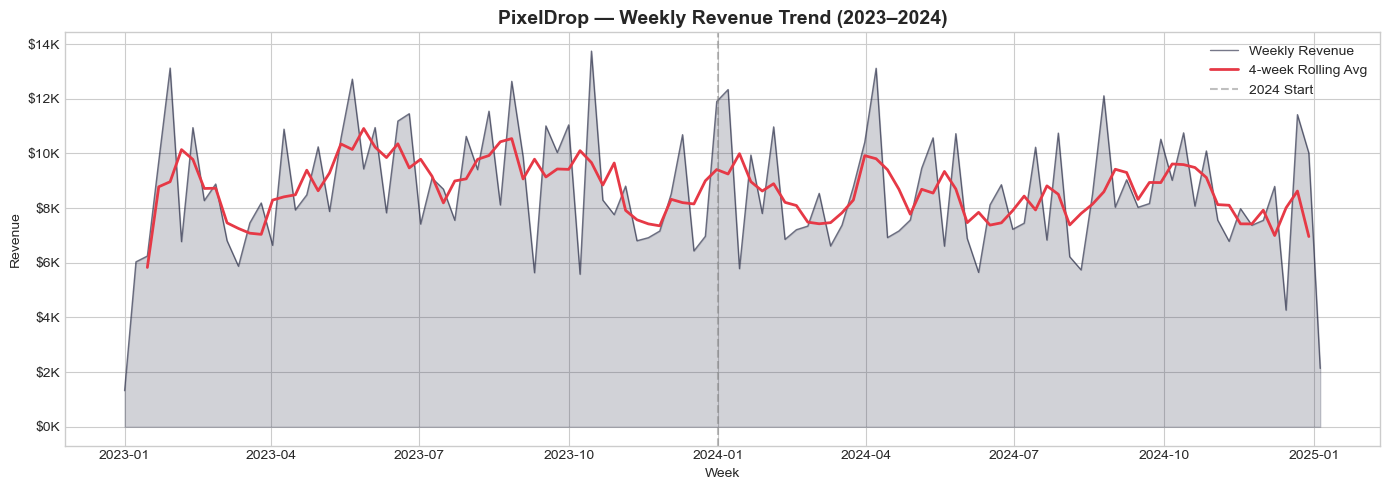

In [2]:
weekly = (
    order_summary
    .groupby('order_date')['line_total']
    .sum()
    .resample('W')
    .sum()
    .reset_index()
)
weekly.columns = ['week_end', 'revenue']

# Rolling average for trend line
weekly['rolling_4w'] = weekly['revenue'].rolling(4, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(weekly['week_end'], weekly['revenue'], alpha=0.2, color=BRAND_COLOR)
ax.plot(weekly['week_end'], weekly['revenue'],     color=BRAND_COLOR,  lw=1.0, alpha=0.6, label='Weekly Revenue')
ax.plot(weekly['week_end'], weekly['rolling_4w'],  color=ACCENT_COLOR, lw=2.0, label='4-week Rolling Avg')

# Year separator
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle='--', alpha=0.5, label='2024 Start')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Week')
ax.set_ylabel('Revenue')
ax.set_title('PixelDrop — Weekly Revenue Trend (2023–2024)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PATH + 'charts/10_weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: Orders Heatmap — Month x Day of Week

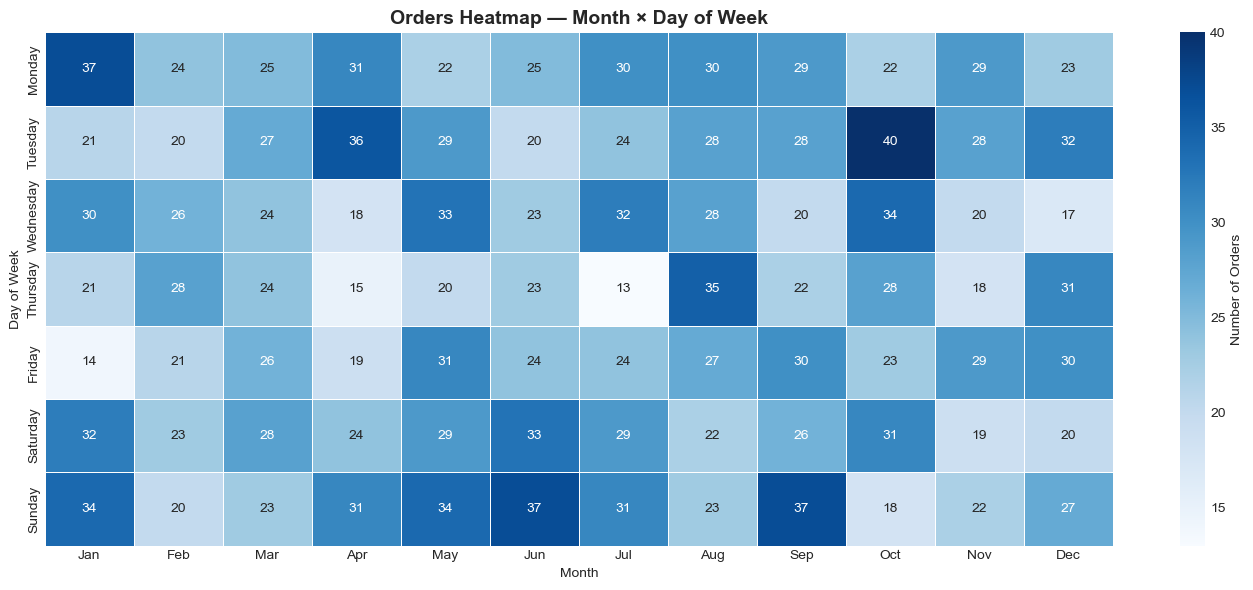

In [3]:
day_order   = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

heatmap_data = (
    order_summary
    .groupby(['month_name', 'day_of_week'])['order_id']
    .nunique()
    .reset_index()
    .pivot(index='day_of_week', columns='month_name', values='order_id')
    .reindex(index=day_order, columns=month_order)
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap='Blues',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Number of Orders'}
)
plt.title('Orders Heatmap — Month × Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig(PATH + 'charts/11_orders_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3: Shipping Days vs Return Rate

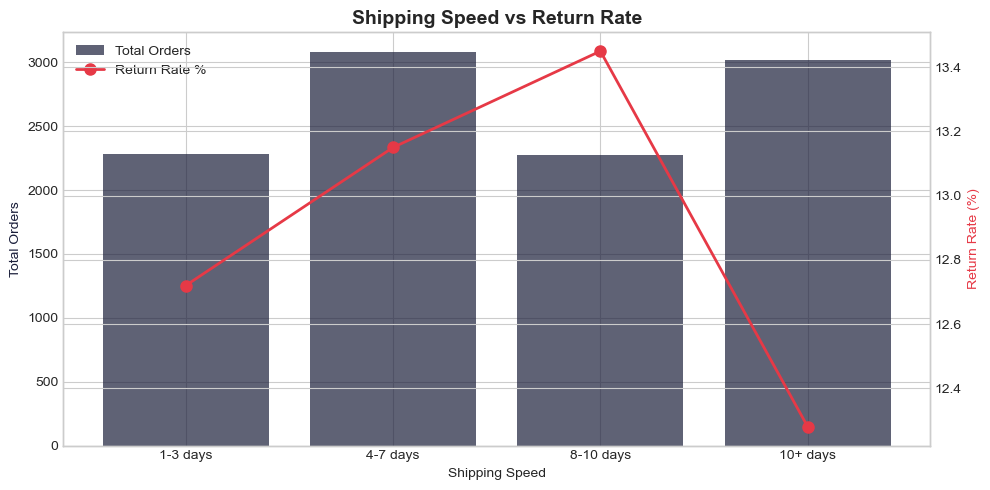

Shipping Analysis:
shipping_bucket  total_orders  total_returns  return_rate_pct
       1-3 days          2280            290            12.72
       4-7 days          3080            405            13.15
      8-10 days          2275            306            13.45
       10+ days          3021            371            12.28


In [4]:
# Create shipping buckets
def shipping_bucket(days):
    if pd.isna(days):   return 'Unknown'
    elif days <= 3:     return '1-3 days'
    elif days <= 7:     return '4-7 days'
    elif days <= 10:    return '8-10 days'
    else:               return '10+ days'

order_summary['shipping_bucket'] = order_summary['shipping_days'].apply(shipping_bucket)

# Orders per bucket
bucket_orders = (
    order_summary[order_summary['shipping_bucket'] != 'Unknown']
    .groupby('shipping_bucket')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
)

# Returns per bucket
returns_with_bucket = returns.merge(
    order_summary[['order_id', 'shipping_bucket']].drop_duplicates(),
    on='order_id', how='left'
)
bucket_returns = (
    returns_with_bucket[returns_with_bucket['shipping_bucket'] != 'Unknown']
    .groupby('shipping_bucket')['return_id']
    .count()
    .reset_index()
    .rename(columns={'return_id': 'total_returns'})
)

shipping_analysis = bucket_orders.merge(bucket_returns, on='shipping_bucket', how='left')
shipping_analysis['return_rate_pct'] = (
    shipping_analysis['total_returns'] / shipping_analysis['total_orders'] * 100
).round(2)

bucket_order = ['1-3 days', '4-7 days', '8-10 days', '10+ days']
shipping_analysis['shipping_bucket'] = pd.Categorical(shipping_analysis['shipping_bucket'], categories=bucket_order, ordered=True)
shipping_analysis = shipping_analysis.sort_values('shipping_bucket')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(shipping_analysis['shipping_bucket'], shipping_analysis['total_orders'], color=BRAND_COLOR, alpha=0.7, label='Total Orders')
ax2.plot(shipping_analysis['shipping_bucket'], shipping_analysis['return_rate_pct'], color=ACCENT_COLOR, marker='o', lw=2, ms=8, label='Return Rate %')

ax1.set_xlabel('Shipping Speed')
ax1.set_ylabel('Total Orders', color=BRAND_COLOR)
ax2.set_ylabel('Return Rate (%)', color=ACCENT_COLOR)
plt.title('Shipping Speed vs Return Rate', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig(PATH + 'charts/12_shipping_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print('Shipping Analysis:')
print(shipping_analysis.to_string(index=False))

## Chart 4: Order Value Distribution

C:\Users\איתי\AppData\Local\Temp\ipykernel_26924\2215272160.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(cat_data, labels=cat_labels, patch_artist=True)


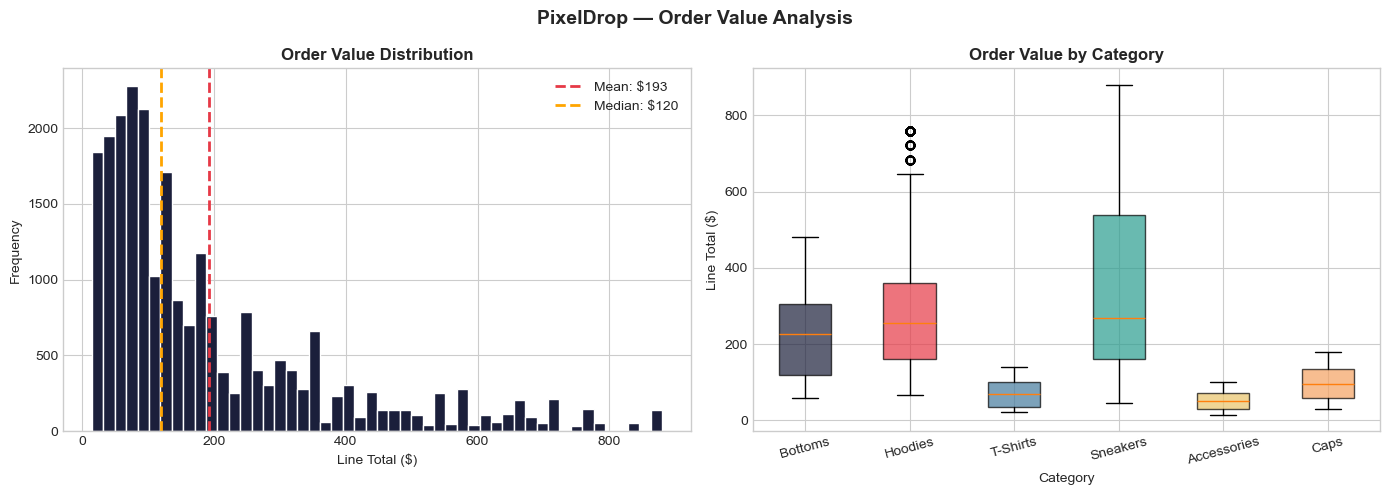

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(order_summary['line_total'].dropna(), bins=50, color=BRAND_COLOR, edgecolor='white')
axes[0].axvline(order_summary['line_total'].mean(),   color=ACCENT_COLOR, linestyle='--', lw=2,
                label=f'Mean: ${order_summary["line_total"].mean():.0f}')
axes[0].axvline(order_summary['line_total'].median(), color='orange',     linestyle='--', lw=2,
                label=f'Median: ${order_summary["line_total"].median():.0f}')
axes[0].set_xlabel('Line Total ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Order Value Distribution', fontweight='bold')
axes[0].legend()

# Box plot by category
cat_data = [order_summary[order_summary['category'] == c]['line_total'].dropna()
            for c in order_summary['category'].dropna().unique()]
cat_labels = list(order_summary['category'].dropna().unique())

bp = axes[1].boxplot(cat_data, labels=cat_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Line Total ($)')
axes[1].set_title('Order Value by Category', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('PixelDrop — Order Value Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PATH + 'charts/13_order_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5: Monthly Revenue with MoM Growth

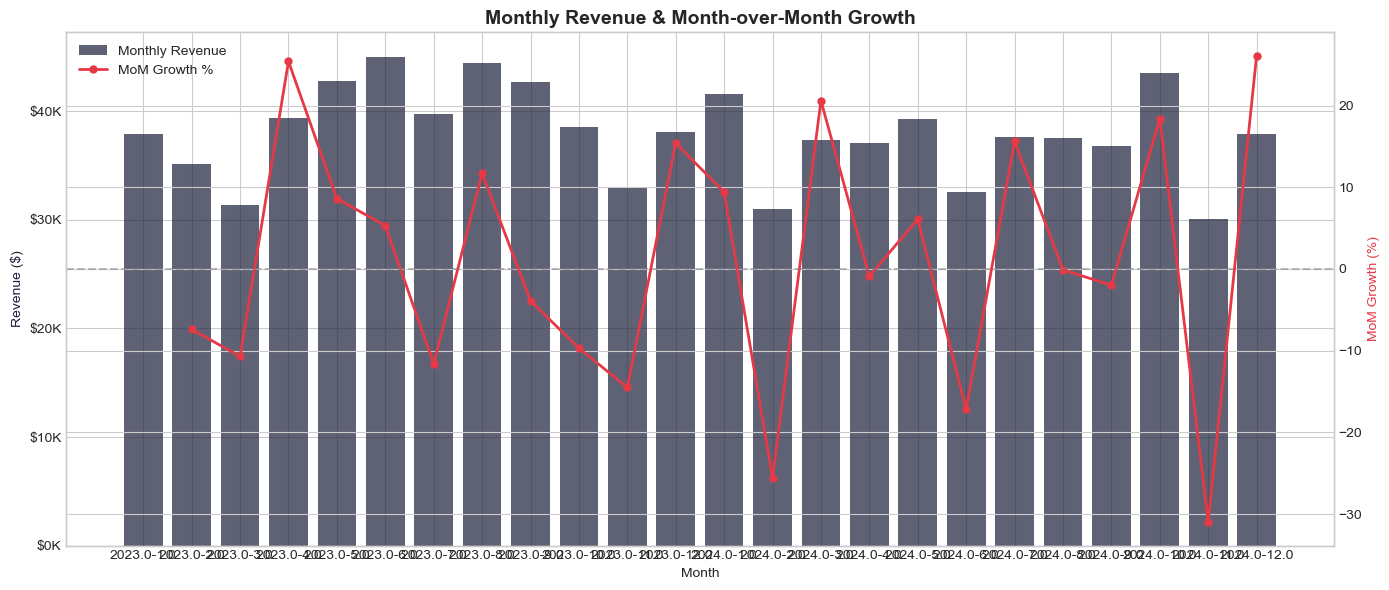

In [6]:
monthly = (
    order_summary
    .groupby(['year', 'month'])['line_total']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
)
monthly['prev_month'] = monthly['line_total'].shift(1)
monthly['mom_growth'] = ((monthly['line_total'] - monthly['prev_month']) / monthly['prev_month'] * 100).round(1)
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(monthly['period'], monthly['line_total'], color=BRAND_COLOR, alpha=0.7, label='Monthly Revenue')
ax2.plot(monthly['period'], monthly['mom_growth'], color=ACCENT_COLOR, marker='o', lw=2, ms=5, label='MoM Growth %')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)', color=BRAND_COLOR)
ax2.set_ylabel('MoM Growth (%)', color=ACCENT_COLOR)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
plt.title('Monthly Revenue & Month-over-Month Growth', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig(PATH + 'charts/14_monthly_revenue_growth.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary — All Charts Saved!

All 14 charts are exported to `clean/charts/` at 150 dpi and ready to embed in a portfolio or slide deck.

| Chart | File | Key Insight |
|-------|------|-------------|
| Revenue by Category | 01_revenue_by_category.png | Sneakers = 36% of revenue |
| Top 5 Products | 02_top5_products.png | Revenue vs volume leaders are entirely different lists |
| Return Rate | 03_return_rate_by_product.png | Air Hoodie highest at 7.31% — likely a sizing issue |
| Discount vs Quantity | 04_discount_vs_quantity.png | Near-zero correlation — discounts don't drive volume |
| Avg Discount | 05_avg_discount_by_category.png | Category discount spread — margin risk indicator |
| Segment Analysis | 06_segment_analysis.png | Loyal segment generates highest revenue per customer |
| Orders by Day | 07_orders_by_day.png | Peak shopping day highlighted |
| Quarterly Revenue | 08_quarterly_revenue.png | 2023 vs 2024 seasonal pattern comparison |
| RFM Analysis | 09_rfm_analysis.png | 406 Champions, 343 At-Risk customers identified |
| Weekly Trend | 10_weekly_revenue_trend.png | 2-year trend with 4-week rolling average smoothing |
| Orders Heatmap | 11_orders_heatmap.png | Month × day-of-week demand pattern |
| Shipping vs Returns | 12_shipping_vs_returns.png | Dual-axis: does slower shipping drive more returns? |
| Order Value Dist | 13_order_value_distribution.png | Distribution shape + box plots by category |
| MoM Growth | 14_monthly_revenue_growth.png | Month-over-month growth rate overlay on revenue bars |

> **Portfolio tip:** Charts 10, 11, and 14 update with full data accuracy after re-running notebooks 02–05 in order — they depend on `order_date` which was affected by a date-parsing fix in Notebook 02.
